# PCA on Police Sketches: Recovering the Drawing Basis

Goal: build a **toy "police sketch" dataset** from a few simple drawing primitives (eyes, nose, mouth, hair), then show that **PCA recovers something very close to those original basis sketches**.

We will:

1. Define a small set of base sketch images (our "true" basis).
2. Create many random linear combinations of those bases (simulated suspect sketches).
3. Run PCA on the random sketches.
4. Compare the learned PCA components with the original bases.
5. Optionally, reconstruct a sketch using only a few principal components.

This gives students an accessible, low‑dimensional version of the idea that will later appear again with **eigenfaces** on the Olivetti faces dataset.

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# For reproducibility
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)


def show_image(img, title=None, cmap="gray"):
    plt.imshow(img, cmap=cmap, vmin=0, vmax=1)
    plt.xticks([])
    plt.yticks([])
    if title:
        plt.title(title)

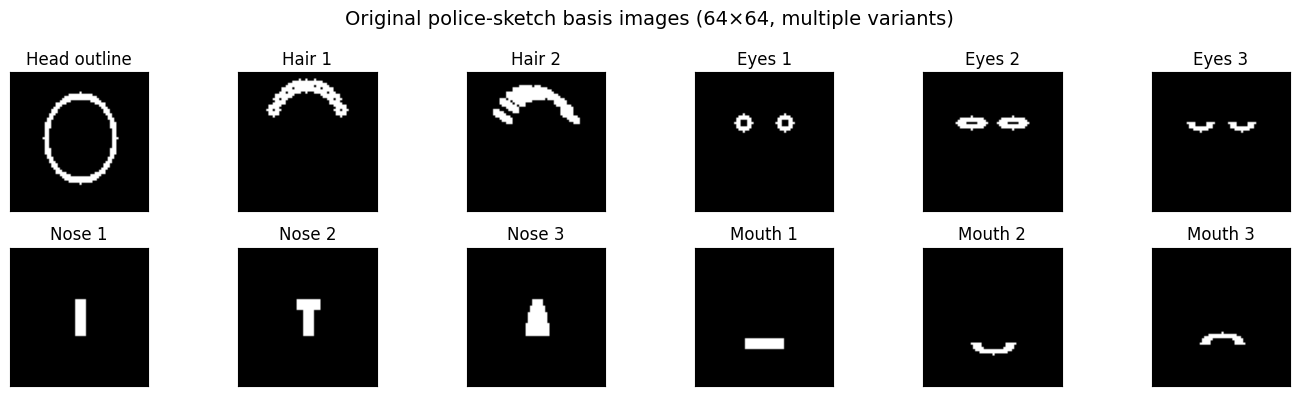

In [38]:
# --------------------------------------------------
# 1. Define more realistic "police sketch" basis images
#    with multiple variants for eyes, nose, mouth
# --------------------------------------------------

H, W = 64, 64  # higher-res sketches so features look like a face


def draw_ellipse(img, center, radii, value=1.0, thickness=2, mask_fn=None):
    cy, cx = center
    ry, rx = radii
    Y, X = np.ogrid[:H, :W]
    dist = ((Y - cy) / ry) ** 2 + ((X - cx) / rx) ** 2
    inner = (ry - thickness) / ry
    inner = max(inner, 0.0)
    mask = (dist <= 1.0) & (dist >= inner ** 2)
    if mask_fn is not None:
        mask &= mask_fn(Y, X)
    img[mask] = value


def draw_circle(img, center, radius, value=1.0, thickness=2):
    draw_ellipse(img, center, (radius, radius), value=value, thickness=thickness)


def draw_line(img, p1, p2, value=1.0, thickness=2):
    y1, x1 = p1
    y2, x2 = p2
    length = int(np.hypot(y2 - y1, x2 - x1)) + 1
    ys = np.linspace(y1, y2, length)
    xs = np.linspace(x1, x2, length)
    for y, x in zip(ys, xs):
        yy = int(round(y))
        xx = int(round(x))
        y0 = max(0, yy - thickness)
        y1 = min(H, yy + thickness + 1)
        x0 = max(0, xx - thickness)
        x1 = min(W, xx + thickness + 1)
        img[y0:y1, x0:x1] = value


# Head outline (single variant)
base_head = np.zeros((H, W))
head_center = (int(0.48 * H), int(0.5 * W))
head_radii = (int(0.34 * H), int(0.27 * W))
draw_ellipse(base_head, head_center, head_radii, value=1.0, thickness=3)

# Hair (two variants) – follow the head curve
base_hair_1 = np.zeros((H, W))  # curly
base_hair_2 = np.zeros((H, W))  # wavy

for t in np.linspace(-0.9, 0.9, 11):
    # Position along the head ellipse (parametrized by horizontal offset t)
    cx = int(head_center[1] + t * head_radii[1])
    inside = 1.0 - t ** 2
    if inside <= 0:
        continue
    cy_top = int(head_center[0] - head_radii[0] * np.sqrt(inside))

    # Curly hair: small circles along the top
    draw_circle(base_hair_1, (cy_top - 3, cx), radius=3, value=1.0, thickness=2)

    # Wavy hair: short diagonal strokes crossing the head boundary
    draw_line(base_hair_2, (cy_top - 2, cx - 3), (cy_top + 2, cx + 3), value=1.0, thickness=1)

# Eyes (three variants)
base_eyes_1 = np.zeros((H, W))
base_eyes_2 = np.zeros((H, W))
base_eyes_3 = np.zeros((H, W))

eye_y = int(0.37 * H)
left_eye_x = int(0.35 * W)
right_eye_x = int(0.65 * W)

# Variant 1: round eyes
draw_circle(base_eyes_1, (eye_y, left_eye_x), radius=4, value=1.0, thickness=2)
draw_circle(base_eyes_1, (eye_y, right_eye_x), radius=4, value=1.0, thickness=2)

# Variant 2: narrow horizontal eyes
draw_ellipse(base_eyes_2, (eye_y, left_eye_x), radii=(3, 7), value=1.0, thickness=2)
draw_ellipse(base_eyes_2, (eye_y, right_eye_x), radii=(3, 7), value=1.0, thickness=2)

# Variant 3: "tired" eyes (half-circles)
mask_lower = lambda Y, X: Y >= eye_y
draw_ellipse(base_eyes_3, (eye_y, left_eye_x), radii=(4, 6), value=1.0, thickness=2, mask_fn=mask_lower)
draw_ellipse(base_eyes_3, (eye_y, right_eye_x), radii=(4, 6), value=1.0, thickness=2, mask_fn=mask_lower)

# Nose (three variants)
base_nose_1 = np.zeros((H, W))
base_nose_2 = np.zeros((H, W))
base_nose_3 = np.zeros((H, W))

nose_top = (int(0.42 * H), int(0.5 * W))
nose_bottom = (int(0.60 * H), int(0.5 * W))

# Variant 1: simple line
draw_line(base_nose_1, nose_top, nose_bottom, value=1.0, thickness=2)

# Variant 2: T-shaped nose (kept clear of the eyes)
draw_line(base_nose_2, (nose_top[0], nose_top[1] - 3), (nose_top[0], nose_top[1] + 3), value=1.0, thickness=2)
draw_line(base_nose_2, nose_top, nose_bottom, value=1.0, thickness=2)

# Variant 3: small triangle nose
draw_line(base_nose_3, (nose_top[0], nose_top[1]), (nose_bottom[0], nose_bottom[1] - 3), value=1.0, thickness=2)
draw_line(base_nose_3, (nose_top[0], nose_top[1]), (nose_bottom[0], nose_bottom[1] + 3), value=1.0, thickness=2)
draw_line(base_nose_3, (nose_bottom[0], nose_bottom[1] - 3), (nose_bottom[0], nose_bottom[1] + 3), value=1.0, thickness=2)

# Mouth (three variants)
base_mouth_1 = np.zeros((H, W))
base_mouth_2 = np.zeros((H, W))
base_mouth_3 = np.zeros((H, W))

mouth_center = (int(0.70 * H), int(0.5 * W))
mouth_radii = (int(0.08 * H), int(0.16 * W))

# Variant 1: flat line (stay inside the head)
draw_line(base_mouth_1, (mouth_center[0], int(0.40 * W)), (mouth_center[0], int(0.60 * W)), value=1.0, thickness=2)

# Variant 2: smile (lower half-ellipse)
mask_lower_mouth = lambda Y, X: Y >= mouth_center[0]
draw_ellipse(base_mouth_2, mouth_center, mouth_radii, value=1.0, thickness=2, mask_fn=mask_lower_mouth)

# Variant 3: frown (upper half-ellipse)
mask_upper_mouth = lambda Y, X: Y <= mouth_center[0]
draw_ellipse(base_mouth_3, mouth_center, mouth_radii, value=1.0, thickness=2, mask_fn=mask_upper_mouth)

# Collect all basis images
base_images = np.array([
    base_head,        # 0
    base_hair_1,      # 1
    base_hair_2,      # 2
    base_eyes_1,      # 3
    base_eyes_2,      # 4
    base_eyes_3,      # 5
    base_nose_1,      # 6
    base_nose_2,      # 7
    base_nose_3,      # 8
    base_mouth_1,     # 9
    base_mouth_2,     # 10
    base_mouth_3,     # 11
])

base_names = [
    "Head outline",
    "Hair 1",
    "Hair 2",
    "Eyes 1",
    "Eyes 2",
    "Eyes 3",
    "Nose 1",
    "Nose 2",
    "Nose 3",
    "Mouth 1",
    "Mouth 2",
    "Mouth 3",
]

plt.figure(figsize=(14, 4))
for i, (img, name) in enumerate(zip(base_images, base_names)):
    plt.subplot(2, 6, i + 1)
    show_image(img, name)

plt.suptitle("Original police-sketch basis images (64×64, multiple variants)", fontsize=14)
plt.tight_layout()
plt.show()

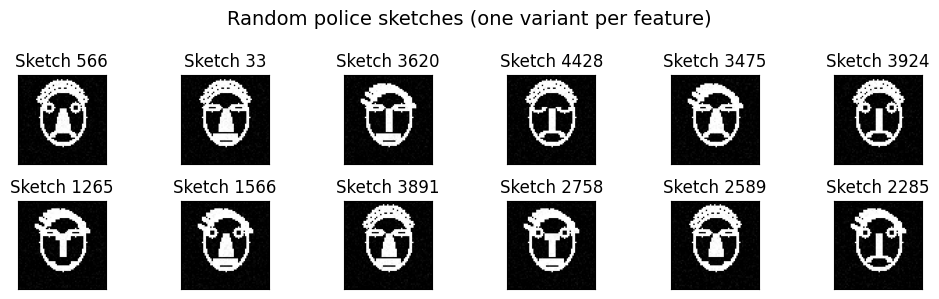

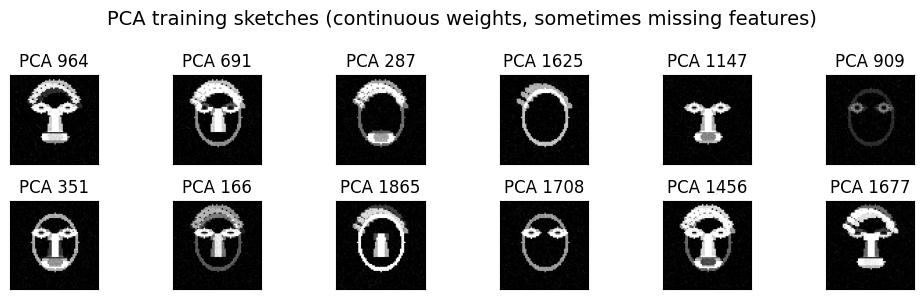

In [39]:
# --------------------------------------------------
# 2. Generate two datasets:
#    - X_vis  : discrete composites for visualization
#    - X_pca : continuous, partially missing features for PCA
# --------------------------------------------------

n_bases = base_images.shape[0]
flat_bases = base_images.reshape(n_bases, -1)  # (n_bases, H*W)

# Indices of variant groups
idx_head = 0
hair_idxs = [1, 2]
eye_idxs = [3, 4, 5]
nose_idxs = [6, 7, 8]
mouth_idxs = [9, 10, 11]

# ------------------------------
# 2a. Discrete composites for visualization
# ------------------------------

n_sketches_vis = 5000
coeffs_vis = np.zeros((n_sketches_vis, n_bases))

for i in range(n_sketches_vis):
    # Always include head outline
    coeffs_vis[i, idx_head] = 1.0
    # Pick exactly one variant from each group
    coeffs_vis[i, rng.choice(hair_idxs)] = 1.0
    coeffs_vis[i, rng.choice(eye_idxs)] = 1.0
    coeffs_vis[i, rng.choice(nose_idxs)] = 1.0
    coeffs_vis[i, rng.choice(mouth_idxs)] = 1.0

# Linear combinations in pixel space
X_vis = coeffs_vis @ flat_bases  # (n_sketches_vis, H*W)

# Add a little noise and clip to [0, 1]
X_vis += 0.03 * rng.normal(size=X_vis.shape)
X_vis = np.clip(X_vis, 0.0, 1.0)

# Show a few example sketches
n_examples = 12
example_idxs = rng.integers(0, n_sketches_vis, size=n_examples)

plt.figure(figsize=(10, 3))
for i, idx in enumerate(example_idxs):
    plt.subplot(2, 6, i + 1)
    show_image(X_vis[idx].reshape(H, W), title=f"Sketch {idx}")

plt.suptitle("Random police sketches (one variant per feature)", fontsize=14)
plt.tight_layout()
plt.show()

# ------------------------------
# 2b. Continuous, partly missing features for PCA
# ------------------------------

n_sketches_pca = 2000
coeffs_pca = rng.uniform(0.0, 1.0, size=(n_sketches_pca, n_bases))

# With some probability, drop each feature group to break correlations
p_keep_head = 0.8 # 0.9
p_keep_other = 0.6 # 0.7

for i in range(n_sketches_pca):
    # Head (usually present)
    if rng.random() > p_keep_head:
        coeffs_pca[i, idx_head] = 0.0
    # Hair / eyes / nose / mouth
    if rng.random() > p_keep_other:
        coeffs_pca[i, hair_idxs] = 0.0
    if rng.random() > p_keep_other:
        coeffs_pca[i, eye_idxs] = 0.0
    if rng.random() > p_keep_other:
        coeffs_pca[i, nose_idxs] = 0.0
    if rng.random() > p_keep_other:
        coeffs_pca[i, mouth_idxs] = 0.0

X_pca = coeffs_pca @ flat_bases  # (n_sketches_pca, H*W)
X_pca += 0.03 * rng.normal(size=X_pca.shape)
X_pca = np.clip(X_pca, 0.0, 1.0)

# Show actual examples from the PCA training dataset
pca_example_idxs = rng.integers(0, n_sketches_pca, size=n_examples)

plt.figure(figsize=(10, 3))
for i, idx in enumerate(pca_example_idxs):
    plt.subplot(2, 6, i + 1)
    show_image(X_pca[idx].reshape(H, W), title=f"PCA {idx}")

plt.suptitle("PCA training sketches (continuous weights, sometimes missing features)", fontsize=14)
plt.tight_layout()
plt.show()

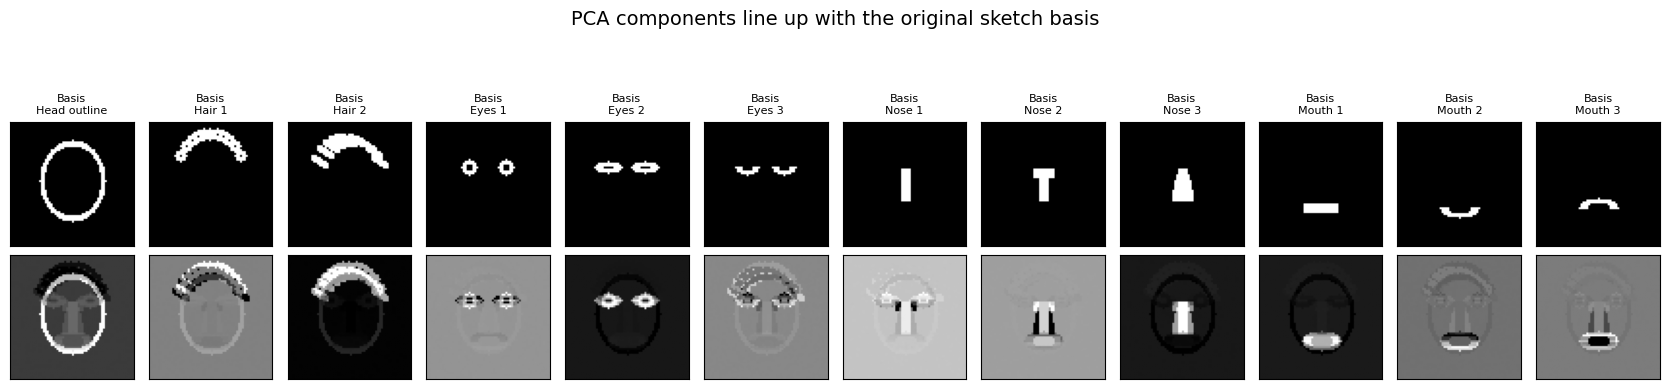

In [40]:
# --------------------------------------------------
# 3. Fit PCA and compare components to the true bases
# --------------------------------------------------

from scipy.optimize import linear_sum_assignment

# Center the PCA dataset before PCA
X_pca_mean_val = X_pca.mean(axis=0, keepdims=True)
X_centered = X_pca - X_pca_mean_val

n_pca_components = n_bases * 2
pca = PCA(n_components=n_pca_components, random_state=RANDOM_STATE)
pca.fit(X_centered)

components = pca.components_  # (n_pca_components, H*W)
components_img = components.reshape(n_pca_components, H, W)

# Align PCA components with the original bases (up to sign and permutation)
B = flat_bases  # (n_bases, H*W)
C = components  # (n_pca_components, H*W)

# Toggle: raw dot product vs cosine similarity.
# Important: do NOT subtract X_pca_mean_val from each sparse basis image here.
# That would add a large "negative mean face" to every basis and make all matches
# look like the population mean/head structure rather than the intended part.
cosine_similarity = False # True

if cosine_similarity:
    def _row_normalize(x):
        norms = np.linalg.norm(x, axis=1, keepdims=True)
        norms = np.clip(norms, 1e-12, None)
        return x / norms

    Cn = _row_normalize(C)
    Bn = _row_normalize(B)
    # Cosine similarity: normalized dot product in pixel space
    corr = Cn @ Bn.T  # (n_pca_components, n_bases)
else:
    # Original behavior: simple unnormalized dot product in pixel space
    corr = C @ B.T  # (n_pca_components, n_bases)


# Find a one-to-one mapping from original bases to PCA components.
# A simple argmax can reuse the same PC for several bases; Hungarian assignment
# chooses the globally best set of distinct PC-to-basis matches.
assignment_score = np.abs(corr)  # higher is better
pc_idxs, basis_idxs = linear_sum_assignment(-assignment_score)

perm = np.empty(n_bases, dtype=int)  # perm[j] = matched PC index for basis j
perm[basis_idxs] = pc_idxs

aligned_components = []
for j, k in enumerate(perm):
    sign = np.sign(corr[k, j])
    if sign == 0:
        sign = 1.0
    aligned_components.append(C[k] * sign)

aligned_components = np.array(aligned_components).reshape(n_bases, H, W)

# Plot: first row = true bases, second row = closest PCA components
fig, axes = plt.subplots(2, n_bases, figsize=(1.4 * n_bases, 4))

for i in range(n_bases):
    # True basis
    ax_top = axes[0, i]
    ax_top.imshow(base_images[i], cmap="gray", vmin=0, vmax=1)
    ax_top.set_xticks([])
    ax_top.set_yticks([])
    ax_top.set_title(f"Basis\n{base_names[i]}", fontsize=8)

    # Matched PCA component (normalize per-component for visibility)
    ax_bottom = axes[1, i]
    var_ratio = pca.explained_variance_ratio_[perm[i]]
    comp = aligned_components[i]
    c_min, c_max = comp.min(), comp.max()
    if c_max > c_min:
        comp_norm = (comp - c_min) / (c_max - c_min)
    else:
        comp_norm = np.zeros_like(comp)
    ax_bottom.imshow(comp_norm, cmap="gray", vmin=0, vmax=1)
    ax_bottom.set_xticks([])
    ax_bottom.set_yticks([])
    ax_bottom.set_title(f"PC {perm[i]}\nvar {var_ratio:.2f}", fontsize=8)

plt.suptitle("PCA components line up with the original sketch basis", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.85])
plt.show()

In [41]:
# --------------------------------------------------
# 4. (Optional) Interactive reconstruction from a few PCs
# --------------------------------------------------

import io

try:
    import ipywidgets as widgets
    from IPython.display import clear_output, display
except ImportError:
    widgets = None


def fig_to_png(fig):
    """Render a matplotlib figure to PNG bytes, then close it."""
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", bbox_inches="tight", dpi=120)
    plt.close(fig)
    return buffer.getvalue()


def reconstruct_example(example_idx=0, n_components=1):
    example_idx = int(example_idx)
    n_components = int(n_components)

    # Use a discrete composite sketch for visualization
    x = X_vis[example_idx]  # (H*W,)

    # True generating weights in the original basis
    true_weights = coeffs_vis[example_idx]  # (n_bases,)

    # Project to PCA space (use the same mean as for PCA training)
    x_centered_single = x.reshape(1, -1) - X_pca_mean_val
    z_full = pca.transform(x_centered_single)  # (1, n_pca_components)

    # Keep only the first n_components, zero out the rest
    z = np.zeros_like(z_full)
    z[:, :n_components] = z_full[:, :n_components]

    # Back to pixel space: first reconstruct in the *centered* space,
    # then add back the training mean used for PCA.
    x_recon_centered = pca.inverse_transform(z)[0]
    x_recon = x_recon_centered + X_pca_mean_val.ravel()
    x_recon = np.clip(x_recon, 0.0, 1.0)

    # Match PCA coordinates (after truncation) to basis order via perm
    matched_pc_weights = np.zeros(n_bases)
    for j in range(n_bases):
        k = perm[j]
        matched_pc_weights[j] = z[0, k]  # PCs beyond n_components are already zero

    # Helper to normalize a 1D weight vector for display
    def norm_vec(v):
        v_abs = np.abs(v)
        vmax = v_abs.max()
        if vmax > 0:
            return v_abs / vmax
        return np.zeros_like(v_abs)

    true_norm = norm_vec(true_weights)
    pc_norm = norm_vec(matched_pc_weights)

    fig, axes = plt.subplots(1, 4, figsize=(10, 3))

    # Original image
    axes[0].imshow(x.reshape(H, W), cmap="gray", vmin=0, vmax=1)
    axes[0].set_title(f"Original sketch\n(index {example_idx})")
    axes[0].set_xticks([])
    axes[0].set_yticks([])

    # Reconstruction
    axes[1].imshow(x_recon.reshape(H, W), cmap="gray", vmin=0, vmax=1)
    axes[1].set_title(f"Reconstruction\nwith {n_components} PCs")
    axes[1].set_xticks([])
    axes[1].set_yticks([])

    # Y positions for basis labels (one row per basis)
    y_pos = np.arange(n_bases)

    # True basis weights (flattened vector)
    axes[2].imshow(true_norm.reshape(-1, 1), cmap="gray", aspect="auto", vmin=0, vmax=1)
    axes[2].set_title("Original basis\nweights", fontsize=8)
    axes[2].set_xticks([])
    axes[2].set_yticks(y_pos)
    axes[2].set_yticklabels(base_names, fontsize=6)

    # PCA / matched-basis weights (flattened vector)
    axes[3].imshow(pc_norm.reshape(-1, 1), cmap="gray", aspect="auto", vmin=0, vmax=1)
    axes[3].set_title("Matched PC\nweights", fontsize=8)
    axes[3].set_xticks([])
    axes[3].set_yticks(y_pos)
    axes[3].set_yticklabels(base_names, fontsize=6)

    plt.tight_layout()
    main_png = fig_to_png(fig)
    basis_png = None

    # Grid of PCA basis images (matched to original bases) with significant weights
    max_w_true = np.abs(true_weights).max()
    max_w_pc = np.abs(matched_pc_weights).max()
    # Bases that truly participated in this sketch
    active = np.where(np.abs(true_weights) > 1e-6)[0]
    if max_w_pc > 0 and len(active) > 0:
        # Among the active bases, sort by |PC weight| (largest first)
        scores = np.abs(matched_pc_weights[active])
        order = np.argsort(-scores)
        # Show at most `n_components` of them, so the grid size
        # responds to the "# of PCs" slider (up to all active bases).
        k = min(n_components, len(active))
        significant = active[order[:k]]

        if len(significant) > 0:
            fig2, axes2 = plt.subplots(
                1, len(significant), figsize=(2.0 * len(significant), 2.5)
            )
            if len(significant) == 1:
                axes2 = [axes2]

            for ax, idx in zip(axes2, significant):
                # Show the matched PCA basis image for this original basis index,
                # normalized per-image for visibility
                comp_img = aligned_components[idx]
                cmin, cmax = comp_img.min(), comp_img.max()
                if cmax > cmin:
                    comp_norm = (comp_img - cmin) / (cmax - cmin)
                else:
                    comp_norm = np.zeros_like(comp_img)

                ax.imshow(comp_norm, cmap="gray", vmin=0, vmax=1)
                ax.set_xticks([])
                ax.set_yticks([])
                ax.set_title(base_names[idx], fontsize=8)
                ax.set_xlabel(
                    f"w={true_weights[idx]:.2f}\npc={matched_pc_weights[idx]:.2f}",
                    fontsize=7,
                )

            plt.tight_layout()
            basis_png = fig_to_png(fig2)

    return main_png, basis_png


if widgets is not None:
    example_slider = widgets.IntSlider(
        value=0,
        min=0,
        max=n_sketches_vis - 1,
        step=1,
        description="Sketch index:",
        continuous_update=False,
        layout=widgets.Layout(width="500px"),
    )

    pc_slider = widgets.IntSlider(
        value=1,
        min=1,
        max=n_bases * 2,
        step=1,
        description="# of PCs:",
        continuous_update=False,
        layout=widgets.Layout(width="500px"),
    )

    main_image = widgets.Image(format="png")
    basis_image = widgets.Image(format="png")
    basis_image.layout.display = "none"

    def update_reconstruction(_=None):
        main_png, basis_png = reconstruct_example(
            example_idx=example_slider.value,
            n_components=pc_slider.value,
        )
        main_image.value = main_png
        if basis_png is None:
            basis_image.value = b""
            basis_image.layout.display = "none"
        else:
            basis_image.value = basis_png
            basis_image.layout.display = ""

    example_slider.observe(update_reconstruction, names="value")
    pc_slider.observe(update_reconstruction, names="value")

    controls = widgets.VBox([example_slider, pc_slider])
    clear_output(wait=True)
    display(widgets.VBox([controls, main_image, basis_image]))
    update_reconstruction()
else:
    print("ipywidgets not installed - skip interactive reconstruction.")

In [42]:
# --------------------------------------------------
# 5. Explore flattened vectors: basis vs. matched PCA component
# --------------------------------------------------

import io

# Precompute flattened aligned PCA components
aligned_flat = aligned_components.reshape(n_bases, -1)  # (n_bases, H*W)

try:
    import ipywidgets as widgets
    from IPython.display import clear_output, display
except ImportError:
    widgets = None


def fig_to_png(fig):
    """Render a matplotlib figure to PNG bytes, then close it."""
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", bbox_inches="tight", dpi=120)
    plt.close(fig)
    return buffer.getvalue()


def show_basis_pc_vectors(basis_idx=0):
    basis_idx = int(basis_idx)

    base_vec = flat_bases[basis_idx]
    pc_vec = aligned_flat[basis_idx]

    # Normalize each vector to [0,1] for visualization
    def norm_vec(v):
        v_min, v_max = v.min(), v.max()
        if v_max > v_min:
            return (v - v_min) / (v_max - v_min)
        return np.zeros_like(v)

    base_norm = norm_vec(base_vec)
    pc_norm = norm_vec(pc_vec)

    fig, axes = plt.subplots(1, 4, figsize=(10, 3))

    # Basis image
    axes[0].imshow(base_norm.reshape(H, W), cmap="gray", vmin=0, vmax=1)
    axes[0].set_title(f"Basis image\n{base_names[basis_idx]}")
    axes[0].set_xticks([])
    axes[0].set_yticks([])

    # PCA image
    axes[1].imshow(pc_norm.reshape(H, W), cmap="gray", vmin=0, vmax=1)
    axes[1].set_title(f"Matched PC image")
    axes[1].set_xticks([])
    axes[1].set_yticks([])

    # Flattened basis vector
    axes[2].imshow(base_norm.reshape(-1, 1), cmap="gray", aspect="auto", vmin=0, vmax=1)
    axes[2].set_title("Basis: 1D vector")
    axes[2].set_xticks([])
    axes[2].set_yticks([])

    # Flattened PC vector
    axes[3].imshow(pc_norm.reshape(-1, 1), cmap="gray", aspect="auto", vmin=0, vmax=1)
    axes[3].set_title("PC: 1D vector")
    axes[3].set_xticks([])
    axes[3].set_yticks([])

    plt.tight_layout()
    return fig_to_png(fig)


if widgets is not None:
    basis_slider = widgets.IntSlider(
        value=0,
        min=0,
        max=n_bases - 1,
        step=1,
        description="Basis index:",
        continuous_update=False,
        layout=widgets.Layout(width="500px"),
    )

    vector_image = widgets.Image(format="png")

    def update_basis_pc_vectors(_=None):
        vector_image.value = show_basis_pc_vectors(basis_idx=basis_slider.value)

    basis_slider.observe(update_basis_pc_vectors, names="value")

    clear_output(wait=True)
    display(widgets.VBox([basis_slider, vector_image]))
    update_basis_pc_vectors()
else:
    print("ipywidgets not installed - flattened vector explorer not shown.")

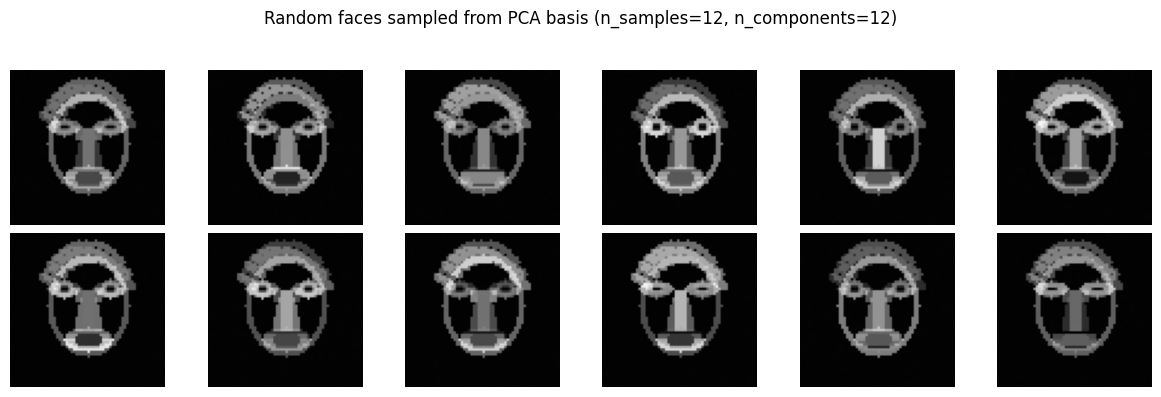

In [43]:
# --------------------------------------------------
# 6. Sample new random faces from the PCA model
# --------------------------------------------------

from math import ceil


def sample_random_pca_faces(n_samples=12, n_components=12, coeff_std=1.0, random_state=None):
    """Generate new faces by sampling random PCA coefficients.

    - Only the first `n_components` PCs are used; the rest are set to zero.
    - Samples are drawn from N(0, coeff_std^2) in PCA space.
    - The PCA training mean `X_pca_mean_val` is added back before clipping.
    """

    n_samples = int(n_samples)
    n_components = int(n_components)
    if n_samples <= 0:
        return

    n_components = max(1, min(n_components, n_pca_components))

    rng_local = np.random.default_rng(random_state)

    Z = np.zeros((n_samples, n_pca_components))
    Z[:, :n_components] = rng_local.normal(scale=coeff_std, size=(n_samples, n_components))

    X_centered_samples = pca.inverse_transform(Z)
    X_samples = X_centered_samples + X_pca_mean_val
    X_samples = np.clip(X_samples, 0.0, 1.0)

    cols = min(6, n_samples)
    rows = ceil(n_samples / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2 * rows))
    axes = np.atleast_2d(axes)

    for i in range(rows * cols):
        r, c = divmod(i, cols)
        ax = axes[r, c]
        ax.axis("off")
        if i < n_samples:
            ax.imshow(X_samples[i].reshape(H, W), cmap="gray", vmin=0, vmax=1)

    plt.suptitle(
        f"Random faces sampled from PCA basis (n_samples={n_samples}, n_components={n_components})",
        fontsize=12,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# Example usage: regenerate this cell to see a new random draw
sample_random_pca_faces(n_samples=12, n_components=12, coeff_std=1.0, random_state=None)

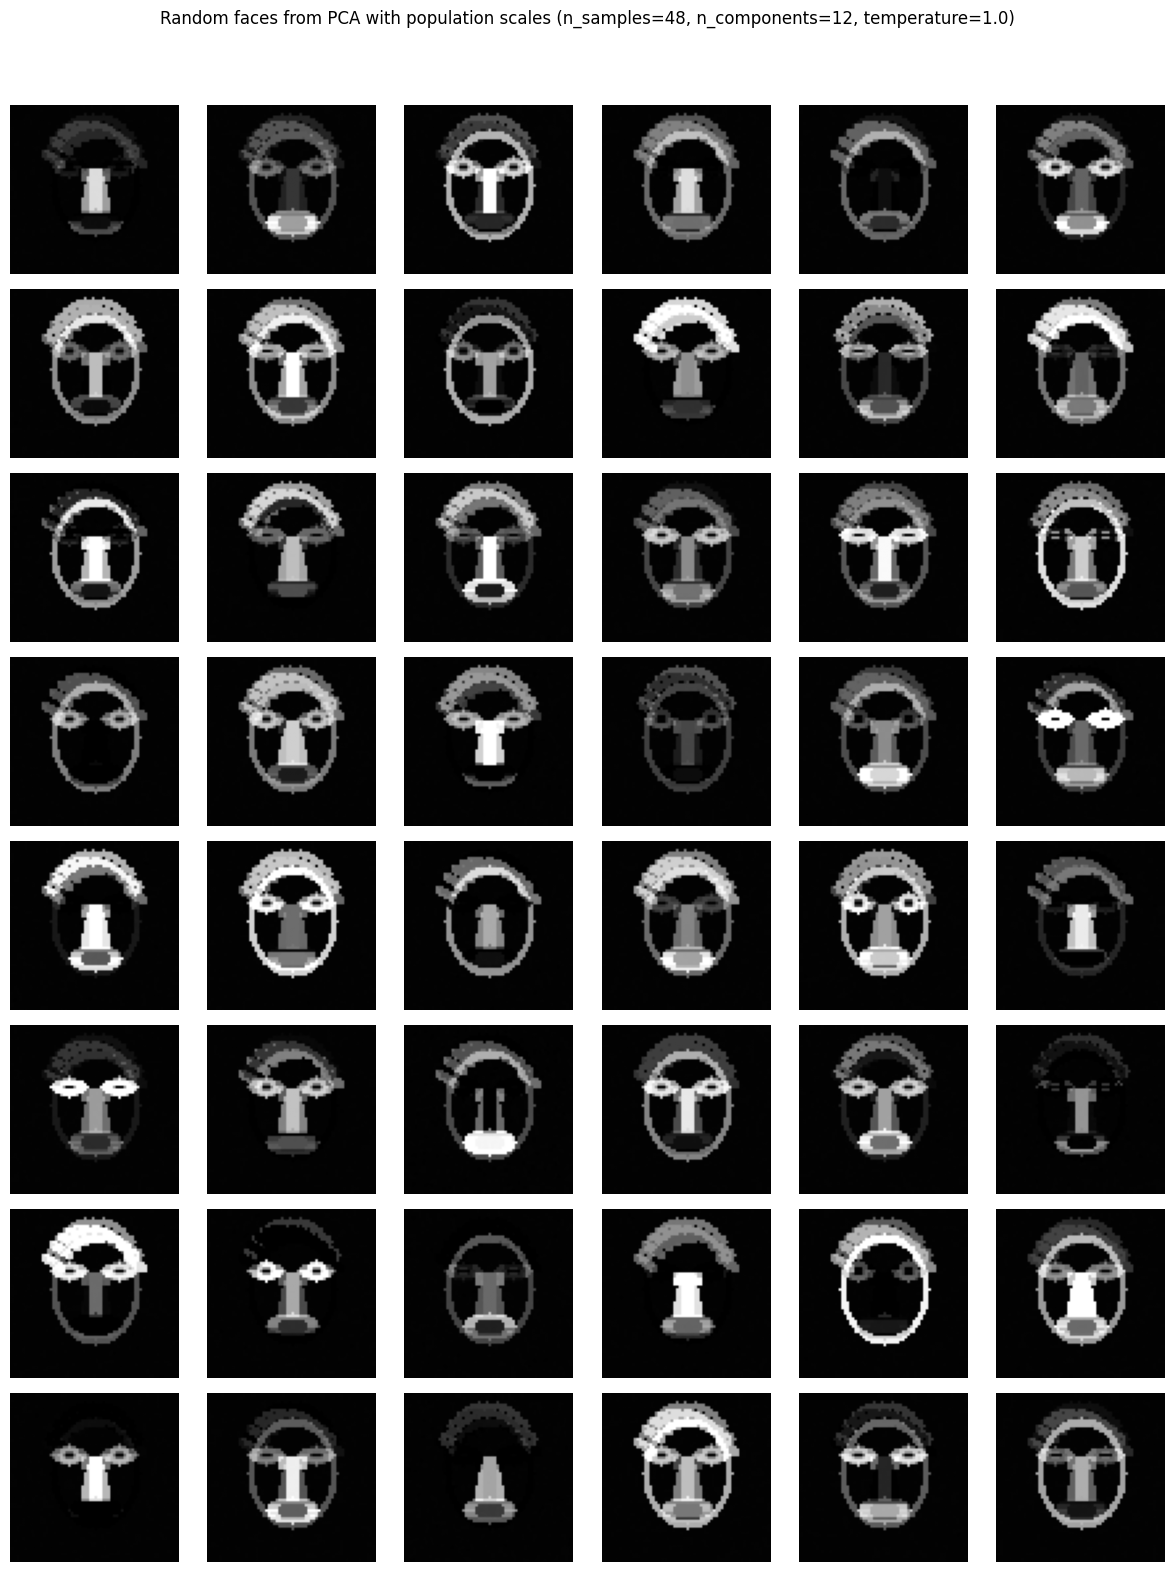

In [44]:
# --------------------------------------------------
# 7. Sample new faces using population-like PCA coefficient scales
# --------------------------------------------------

from math import ceil


def sample_population_pca_faces(
    n_samples=12,
    n_components=12,
    temperature=1.0,
    random_state=None,
):
    """Generate new faces by sampling PCA coefficients with data-driven scales.

    We treat the PCA scores (coordinates) as approximately Gaussian:
    - For component k, the empirical variance in the data is pca.explained_variance_[k].
    - We sample z_k ~ N(0, temperature^2 * explained_variance_[k]).

    For n_components < total, only the first n_components PCs are active; the rest are zero.
    This approximates sampling from a Gaussian fitted to the PCA scores of X_pca.
    """

    n_samples = int(n_samples)
    n_components = int(n_components)
    if n_samples <= 0:
        return

    n_components = max(1, min(n_components, n_pca_components))

    rng_local = np.random.default_rng(random_state)

    # Standard deviations per PC based on training distribution
    # (explained_variance_ is the variance of the scores along each PC)
    pc_stds = np.sqrt(pca.explained_variance_)

    Z = np.zeros((n_samples, n_pca_components))
    # Broadcast stds over samples, scaled by "temperature"
    scales = temperature * pc_stds[:n_components]
    Z[:, :n_components] = rng_local.normal(scale=scales, size=(n_samples, n_components))

    X_centered_samples = pca.inverse_transform(Z)
    X_samples = X_centered_samples + X_pca_mean_val
    X_samples = np.clip(X_samples, 0.0, 1.0)

    cols = min(6, n_samples)
    rows = ceil(n_samples / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2 * rows))
    axes = np.atleast_2d(axes)

    for i in range(rows * cols):
        r, c = divmod(i, cols)
        ax = axes[r, c]
        ax.axis("off")
        if i < n_samples:
            ax.imshow(X_samples[i].reshape(H, W), cmap="gray", vmin=0, vmax=1)

    plt.suptitle(
        f"Random faces from PCA with population scales (n_samples={n_samples}, n_components={n_components}, temperature={temperature})",
        fontsize=12,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# Example usage: faces whose PCA coefficients roughly match the training distribution
sample_population_pca_faces(n_samples=48, n_components=12, temperature=1.0, random_state=None)

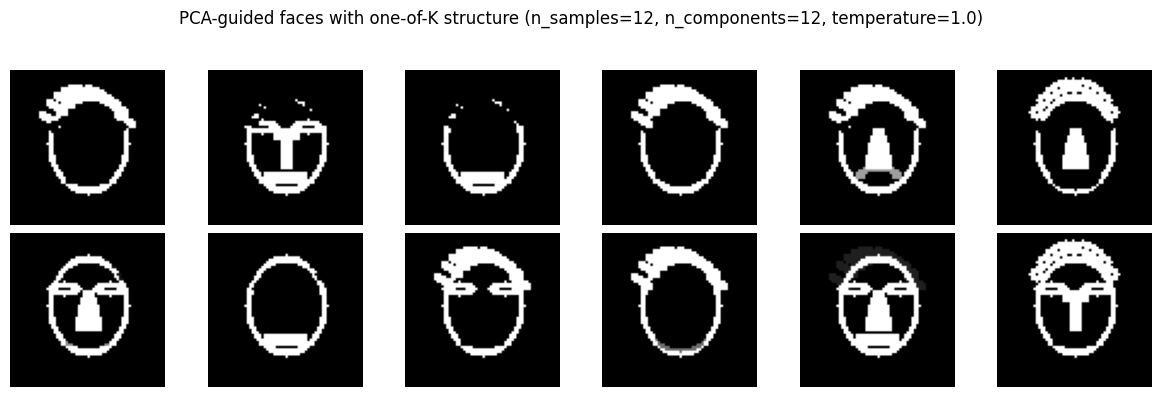

In [45]:
# --------------------------------------------------
# 8. PCA-guided faces with one-of-K feature structure
# --------------------------------------------------

from math import ceil


def sample_pca_guided_structured_faces(
    n_samples=12,
    n_components=12,
    temperature=1.0,
    random_state=None,
):
    """Sample new faces using PCA but enforce the original one-of-K structure.

    Pipeline for each sample:
    1. Draw PCA scores z ~ N(0, diag(temperature^2 * explained_variance_)).
    2. Map z to the original basis order using `perm` (matched PCs).
    3. For each feature group (hair, eyes, nose, mouth), keep only the variant
       with the largest |suggested weight| and zero out the others.
    4. Reconstruct the image *in the original basis* via W @ flat_bases.

    This keeps the combinatorial "exactly one variant per group" rule while
    letting PCA decide *which* variant is most active.
    """

    n_samples = int(n_samples)
    n_components = int(n_components)
    if n_samples <= 0:
        return

    n_components = max(1, min(n_components, n_pca_components))

    rng_local = np.random.default_rng(random_state)

    # 1. Sample PCA scores with data-driven scales (as in population sampler)
    pc_stds = np.sqrt(pca.explained_variance_)
    Z = np.zeros((n_samples, n_pca_components))
    scales = temperature * pc_stds[:n_components]
    Z[:, :n_components] = rng_local.normal(scale=scales, size=(n_samples, n_components))

    # 2. Map PCA scores into the original basis order via perm
    W_suggested = np.zeros((n_samples, n_bases))
    for j in range(n_bases):
        k = perm[j]
        W_suggested[:, j] = Z[:, k]

    # 3. Impose one-of-K constraints per feature group
    head_idx = 0
    groups = [hair_idxs, eye_idxs, nose_idxs, mouth_idxs]

    # Use a distinct name to avoid shadowing the global image width `W`
    W_struct = np.zeros_like(W_suggested)

    for i in range(n_samples):
        # Always include the head outline with unit weight
        W_struct[i, head_idx] = 1.0

        # For each group, pick the variant with the largest |suggested weight|
        for grp in groups:
            grp = list(grp)
            sub = W_suggested[i, grp]
            if np.allclose(sub, 0.0):
                continue  # group effectively absent
            rel = int(np.argmax(np.abs(sub)))
            j = grp[rel]
            amp = sub[rel]
            if amp == 0.0:
                continue
            W_struct[i, j] = amp

    # 4. Reconstruct in the original basis
    X_samples = W_struct @ flat_bases
    X_samples = np.clip(X_samples, 0.0, 1.0)

    cols = min(6, n_samples)
    rows = ceil(n_samples / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2 * rows))
    axes = np.atleast_2d(axes)

    for i in range(rows * cols):
        r, c = divmod(i, cols)
        ax = axes[r, c]
        ax.axis("off")
        if i < n_samples:
            ax.imshow(X_samples[i].reshape(H, W), cmap="gray", vmin=0, vmax=1)

    plt.suptitle(
        f"PCA-guided faces with one-of-K structure (n_samples={n_samples}, n_components={n_components}, temperature={temperature})",
        fontsize=12,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# Example usage: PCA-guided discrete sketches
sample_pca_guided_structured_faces(n_samples=12, n_components=12, temperature=1.0, random_state=None)